<a href="https://colab.research.google.com/github/thaisNY/Ciencias-Dados-PretaLab/blob/main/Copy_of_Ciclo_15_Aula_11_Estat%C3%ADstica_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Se a Netflix diz que você tem 98% de chance de gostar de um filme, você confia? Se sim, por quê?

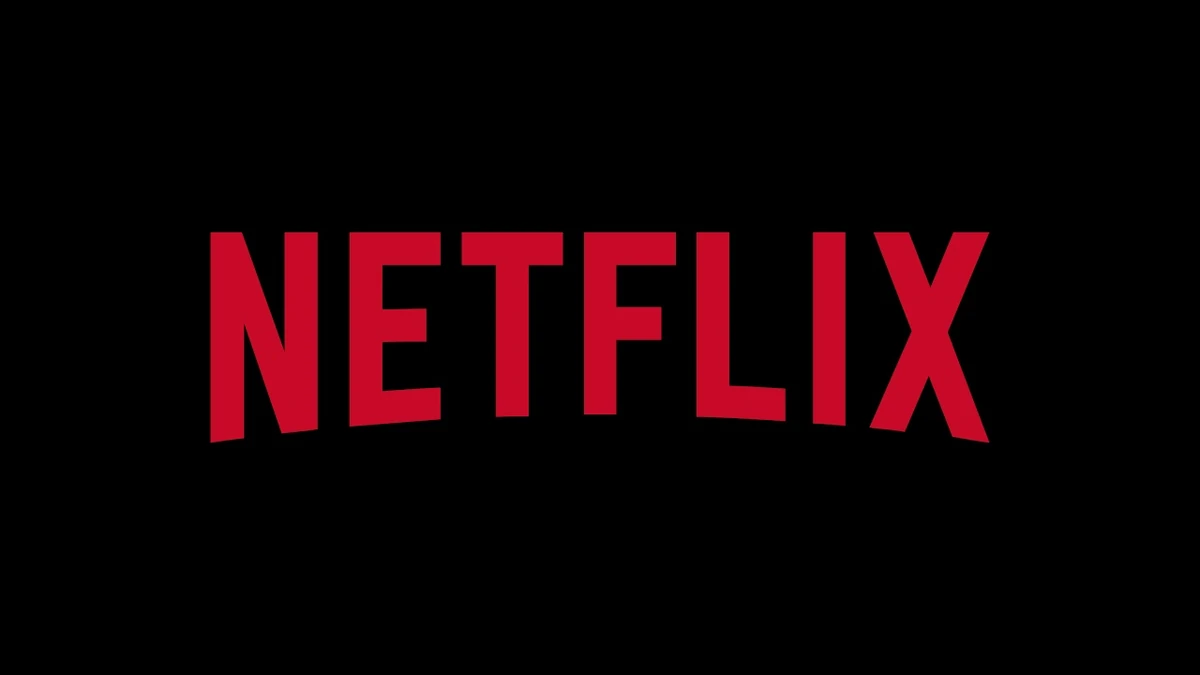

**Onde mais a probabilidade está no nosso cotidiano?** Compartilhe no chat.

# Introdução à Probabilidade


In [ ]:
#Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 1. Conceitos Fundamentais de Probabilidade


Para lidar cientificamente com experimentos do cotidiano, necessitamos de formulações matemáticas para ambos (determinísticos e aleatórios). Para isso, modelos teóricos são construídos para cada caso. Por exemplo, a Física clássica lida com problemas em experimentos determinísticos e a Estatística lida com problemas em experimentos aleatórios.

A **probabilidade** é uma forma matematicamente coerente de medir a **chance de um evento ocorrer**.

\[
P(A) = número de casos favoráveis/número total de casos possíveis
\]

### **Exemplo simples: Cara ou Coroa**

A probabilidade de cara (ou coroa) é de 50%, pois existem dois resultados possíveis e ambos têm a mesma chance.

In [ ]:
p_cara = 1/2
p_coroa = 1/2

### **Exemplo: Lançamento de Dado**

In [ ]:
p_2_dado = 1/6

p_par_dado = 3/6 = 1/2
p_impar_dado = 1/2

In [ ]:

lancamentos1 = np.random.randint(1, 7, 10)
lancamentos1

array([4, 6, 6, 2, 1, 2, 6, 1, 4, 3])

In [ ]:
# Probabilidade de sair um número par
np.sum(lancamentos1%2==0)/len(lancamentos1)

np.float64(0.7)

In [ ]:
lancamentos2 = np.random.randint(1, 7, 10000)
lancamentos2

array([4, 5, 3, ..., 3, 4, 6])

In [ ]:
np.sum(lancamentos2%2==0)/len(lancamentos2)

np.float64(0.5008)

### Criando um modelo probabilístico

Basicamente, a teoria é baseada na construção de um modelo matemático para representar e tratar experimentos aleatórios. Esta construção pode ser sumarizada em dois passos:

1. Para cada experimento aleatório, descreva todo o conjunto de possíveis resultados;

2. “Atribua pesos” a cada possível resultado que reflita a sua chance de ocorrência durante a realização do experimento.


Assim, para descrever o conjunto de possíveis resultados de um experimento, temos a importância da definição do conceito de espaço amostral.

O **Espaço amostral** é um conjunto de (todos) possíveis resultados que podemos ter ao realizar um experimento aleatório.  Ele pode ser finito, infinito enumerável ou, simplesmente, infinito. Cada resultado possível é chamado de ponto ou evento elementar

In [ ]:
espaco_amostral_moeda = {'Cara', 'Coroa'}
print(f"Espaço Amostral da Moeda: {espaco_amostral_moeda}")
print(f"Tamanho (n): {len(espaco_amostral_moeda)}")

Espaço Amostral da Moeda: {'Cara', 'Coroa'}
Tamanho (n): 2


In [ ]:
import itertools

# Experimento: Lançar duas moedas
moeda = ['Cara', 'Coroa']
espaco_2_moedas = list(itertools.product(moeda, repeat=2))

print("Espaço Amostral (2 moedas):")
for resultado in espaco_2_moedas:
    print(resultado)

print(f"Total de combinações possíveis: {len(espaco_2_moedas)}")

Espaço Amostral (2 moedas):
('Cara', 'Cara')
('Cara', 'Coroa')
('Coroa', 'Cara')
('Coroa', 'Coroa')
Total de combinações possíveis: 4


In [ ]:
# Experimento: Lançar um dado de 6 faces
espaco_amostral_dado = list(range(1, 7))
print(f"\nEspaço Amostral do Dado: {espaco_amostral_dado}")
print(f"Tamanho (n): {len(espaco_amostral_dado)}")


Espaço Amostral do Dado: [1, 2, 3, 4, 5, 6]
Tamanho (n): 6


### Tipos de Eventos

| Tipo                      | Descrição                                 | Exemplo                    |
| ------------------------- | ----------------------------------------- | -------------------------- |
| **Mutuamente exclusivos** | Um evento impede o outro                  | Cara ou coroa              |
| **Independentes**         | Um evento não afeta o outro               | Lançar duas moedas         |
| **Dependentes**           | Um evento altera a probabilidade do outro | Tirar cartas sem reposição |


### Lei da probabilidade composta

P(A∩B)=P(A)×P(B)

**A Intuição: O Filtro do "E"**

Calcular a probabilidade de $A$ e $B$ acontecerem juntos é como olhar para a intersecção de dois grupos.

**Evento A:** Ser uma música de Pop.

**Evento B:** Ter uma batida rápida (Tempo > 120).

**A ∩ B:** Apenas as músicas que atendem aos dois critérios ao mesmo tempo.

Regra de Ouro: **negrito** "Na probabilidade, o 'E' vira uma multiplicação ($\times$)". Como estamos multiplicando números entre 0 e 1 (frações), o resultado será sempre menor que as probabilidades individuais.

In [ ]:
# Qual a probabilidade de sair "cara" em dois lançamentos?
p_duas_caras = 1/4

p_duas_caras = p_cara*p_cara = 1/2*1/2 = 1/4

*💡 Quando você busca no LinkedIn por 'Python' E 'Vaga Júnior' E 'Remoto', você está aplicando essa lei.*

### Exercícios Práticos - Probabilidade

1. Um dado de 6 faces é lançado uma vez.

* Qual é a probabilidade de sair um número ímpar?

* Qual é a probabilidade de sair um número maior que 4?

* Faça uma simulação em Python com 10.000 lançamentos para verificar se a probabilidade empírica (observada) se aproxima da teórica.

In [1]:
#a p = 3/6 = 1/2
# b p = 2/6 = 1/3

import itertools
import random

# Configurações
faces = [1, 2, 3, 4, 5, 6]
n_lancamentos_simulacao = 10000

# Probabilidades Teóricas (calculadas na Parte 1)
teorica_impar = 0.50
teorica_maior4 = 1/3

# --- Parte da Simulação ---

# 1. Usamos itertools.product para gerar TODAS as possíveis sequências
# de 5 lançamentos. Isso cria um espaço amostral de 6^5 = 7.776 sequências.
# Usamos repeat menor que n_lancamentos para não estourar a memória.
espaco_sequencias = list(itertools.product(faces, repeat=5))

# 2. Para simular 10.000 lançamentos INDIVIDUAIS, sorteamos
# aleatoriamente n_lancamentos dessas sequências e pegamos o primeiro dado de cada uma.
# Isso garante aleatoriedade vinda de um espaço gerado pelo itertools.
amostra_sequencias = random.choices(espaco_sequencias, k=n_lancamentos_simulacao)

# Extraímos o primeiro lançamento de cada sequência sorteada
lancamentos_simulados = [sequencia[0] for sequencia in amostra_sequencias]


# 3. Contagem dos eventos na simulação
total_impares = sum(1 for x in lancamentos_simulados if x % 2 != 0)
total_maior4 = sum(1 for x in lancamentos_simulados if x > 4)

# 4. Cálculo das probabilidades empíricas
empirica_impar = total_impares / n_lancamentos_simulacao
empirica_maior4 = total_maior4 / n_lancamentos_simulacao

# --- Resultados ---
print(f"Resultados da Simulação com {n_lancamentos_simulacao:,} lançamentos (via itertools/choices):")
print("-" * 60)
print(f"{'Evento':<20} | {'Prob. Teórica':<15} | {'Prob. Empírica':<15} | {'Diferença':<10}")
print("-" * 60)
print(f"{'Número Ímpar':<20} | {teorica_impar:<15.4f} | {empirica_impar:<15.4f} | {abs(teorica_impar - empirica_impar):.4f}")
print(f"{'Número > 4':<20} | {teorica_maior4:<15.4f} | {empirica_maior4:<15.4f} | {abs(teorica_maior4 - empirica_maior4):.4f}")
print("-" * 60)
print("A probabilidade empírica se aproxima da teórica, conforme a Lei dos Grandes Números.")



Resultados da Simulação com 10,000 lançamentos (via itertools/choices):
------------------------------------------------------------
Evento               | Prob. Teórica   | Prob. Empírica  | Diferença 
------------------------------------------------------------
Número Ímpar         | 0.5000          | 0.5019          | 0.0019
Número > 4           | 0.3333          | 0.3286          | 0.0047
------------------------------------------------------------
A probabilidade empírica se aproxima da teórica, conforme a Lei dos Grandes Números.


In [3]:
#kizzy
import numpy as np
import matplotlib.pyplot as plt

p_numero_impar = 1/2
print("Probabilidade número ímpar: ", p_numero_impar)

p_maior_4 = 1/3
print("Probabilidade maior que 4: ", p_maior_4)

lancamentos3 = np.random.randint(1, 7, 10000)
lancamentos3

p_emp_impar = np.sum(lancamentos3%2 !=0)/len(lancamentos3)
print("Probabilidade empírica número ímpar: ", p_emp_impar)

p_emp_maior4 = np.sum(lancamentos3 > 4)/len(lancamentos3)
print("Probabilidade empírica maior que 4: ", p_emp_maior4)

Probabilidade número ímpar:  0.5
Probabilidade maior que 4:  0.3333333333333333
Probabilidade empírica número ímpar:  0.5035
Probabilidade empírica maior que 4:  0.3329


2. “Qual é a chance de um aluno atingir determinada nota?”

Contexto: Suponha que temos um conjunto de dados com as notas de 1000 estudantes no ENEM (nota geral de 0 a 1000). Queremos saber:

* Qual é a probabilidade de um aluno tirar nota acima de 700?

* E a chance de tirar abaixo de 500?

In [ ]:
#acima de 700, 300/1000. 3/10
# 500/1000 = 5/10 = 1/2

import numpy as np
import matplotlib.pyplot as plt

nota_maior700 =

In [4]:
notas = np.random.uniform(0,1001, 1000)

In [5]:
notas[0]

np.float64(121.61578656991972)

In [6]:
p_acima_700 = np.sum(notas>700)/len(notas)
p_acima_700

np.float64(0.293)

In [7]:
p_abaixo_500 = np.sum(notas<500)/len(notas)
p_abaixo_500

np.float64(0.525)

## 2. Distribuições de Probabilidade

Uma distribuição de probabilidade descreve como os valores possíveis de uma variável aleatória se comportam.

👉 Em outras palavras: É o padrão de comportamento que descreve quais valores são mais prováveis e quais são mais raros de ocorrer.

### Tipos principais de distribuição de probabilidade

| Tipo         | Descrição                         | Exemplo                                |
| ------------ | --------------------------------- | -------------------------------------- |
| **Discreta** | Resultados contáveis (finitos)    | Dado, cara ou coroa, número de acertos |
| **Contínua** | Resultados em uma escala contínua | Altura, peso, notas do ENEM            |


### 🔹 Distribuição Uniforme

Todos os valores têm a mesma chance de ocorrer.

Exemplos:

- Probabilidade de um número entre 0 e 10 ser sorteado — todos têm a mesma chance.

- O sorteio de um número de bingo, ou o lançamento de um dado honesto.

- No Spotify: Imagine uma playlist onde o "Shuffle" (aleatório) é perfeito: cada música tem exatamente a mesma chance de ser a próxima.

In [ ]:
valores = np.random.randint(0, 11, 10000)

plt.hist(valores, bins=20, color='teal', edgecolor='black')
plt.title('Distribuição Uniforme (0 a 10)')
plt.show()

### 🔹 Distribuição Normal (Gaussiana)

A famosa “curva em forma de sino”, muito comum em fenômenos naturais.

Muitos fenômenos reais seguem essa distribuição — altura, peso, notas, consumo etc.

Características: A média, mediana e moda são iguais, e os dados se concentram em torno do centro.

In [ ]:
dados_normais = np.random.normal(100, 15, 1000)
plt.hist(dados_normais, bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.title('Distribuição Normal (média=100, desvio=15)')
plt.show()

Características:

* Média, mediana e moda são iguais;

* 68% dos valores estão a ±1σ da média;

* 95% estão a ±2σ;

* 99,7% estão a ±3σ.

In [ ]:
dados = np.random.normal(100, 15, 1000)
sns.histplot(dados, kde=True, color='purple')
plt.axvline(100, color='black', linestyle='--', label='Média')
plt.axvline(115, color='red', linestyle='--', label='+1σ')
plt.axvline(85, color='red', linestyle='--', label='-1σ')
plt.legend()
plt.title('Distribuição Normal e Desvio Padrão')
plt.show()

## 🔹 Distribuição Assimétrica (Skewed)


Muitas vezes, os dados não são bonitinhos como o sino.
Na Assimetria Positiva, a maioria dos dados está na esquerda (valores baixos), mas há uma "cauda" longa para a direita (poucos valores muito altos).

Exemplo Real: Distribuição de renda no Brasil (muita gente ganha pouco, pouquíssima gente ganha muito).

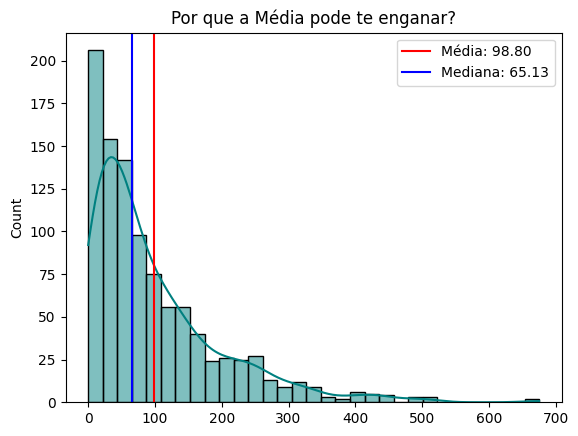

In [ ]:

# Criando dados assimétricos (Renda ou Popularidade)
dados_assimetricos = np.random.exponential(scale=100, size=1000)

media = np.mean(dados_assimetricos)
mediana = np.median(dados_assimetricos)

sns.histplot(dados_assimetricos, kde=True, color='teal')
plt.axvline(media, color='red', label=f'Média: {media:.2f}')
plt.axvline(mediana, color='blue', label=f'Mediana: {mediana:.2f}')
plt.title('Por que a Média pode te enganar?')
plt.legend()
plt.show()

A Média (linha vermelha) é puxada pelos valores altos, mas a Mediana (linha azul) está mais perto de onde a maioria das pessoas realmente está. Em dados reais e desiguais, a mediana costuma ser uma 'líder' mais justa para representar o grupo."

### Por que observar a distribuição é importante?

| Motivo                 | O que permite fazer                           | Exemplo ENEM                                   |
| ---------------------- | --------------------------------------------- | ---------------------------------------------- |
| Entender comportamento | Saber se há simetria, dispersão, concentração | Ver que a maioria das notas está entre 500–700 |
| Detectar outliers      | Identificar valores fora do padrão            | Um aluno com 950 pontos                        |
| Escolher testes e modelos       | Aplicar métodos adequados                     | Ver se pode usar teste t                       |
| Comunicar melhor       | Tornar resultados visuais e claros            | Mostrar curva de notas                         |
| Apoiar decisões        | Tomar ações baseadas nos padrões              | Focar apoio em alunos com notas < 500          |


http://leg.ufpr.br/~ara/teach/ebas/handout_08.html

## Exercício — Distribuição de Probabilidade
Analise o comportamento da variável `valor` no dataset `vendas_cafereria.csv` e responda:

- A distribuição é simétrica ou assimétrica?

- Existem valores atípicos (outliers)?

- O comportamento se aproxima de uma distribuição normal?

In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv('vendas_cafeteria.csv')

In [10]:
df

,hora_do_dia,tipo_pagamento,valor,nome_cafe,periodo_do_dia,dia_da_semana,mes,ordem_dia,ordem_mes,data,hora
0,10,cartão,38.70,Latte,Manhã,Sex,Março,5,3,2024-03-01,10:15:50.520000
1,12,cartão,38.70,Chocolate Quente,Tarde,Sex,Março,5,3,2024-03-01,12:19:22.539000
2,12,cartão,38.70,Chocolate Quente,Tarde,Sex,Março,5,3,2024-03-01,12:20:18.089000
3,13,cartão,28.90,Café Americano,Tarde,Sex,Março,5,3,2024-03-01,13:46:33.006000
4,13,cartão,38.70,Latte,Tarde,Sex,Março,5,3,2024-03-01,13:48:14.626000
...,...,...,...,...,...,...,...,...,...,...,...
3542,10,dinheiro,35.76,Capuccino,Manhã,Dom,Março,7,3,2025-03-23,10:34:54.894000
3543,14,dinheiro,35.76,Cocoa,Tarde,Dom,Março,7,3,2025-03-23,14:43:37.362000
3544,14,dinheiro,35.76,Cocoa,Tarde,Dom,Março,7,3,2025-03-23,14:44:16.864000
3545,15,dinheiro,25.96,Café Americano,Tarde,Dom,Março,7,3,2025-03-23,15:47:28.723000


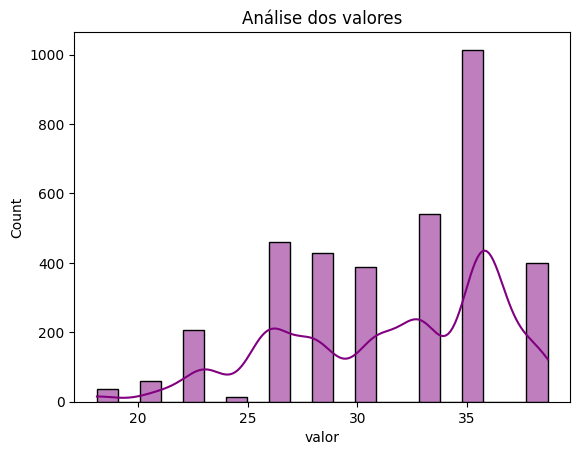

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criando o gráfico
sns.histplot(df['valor'], kde=True, color='purple')
plt.title("Análise dos valores")
plt.show()

In [3]:
#kizzy
import pandas as pd

vendas = pd.read_csv('vendas_cafeteria.csv')

In [4]:
vendas.head()

,hora_do_dia,tipo_pagamento,valor,nome_cafe,periodo_do_dia,dia_da_semana,mes,ordem_dia,ordem_mes,data,hora
0,10,cartão,38.7,Latte,Manhã,Sex,Março,5,3,2024-03-01,10:15:50.520000
1,12,cartão,38.7,Chocolate Quente,Tarde,Sex,Março,5,3,2024-03-01,12:19:22.539000
2,12,cartão,38.7,Chocolate Quente,Tarde,Sex,Março,5,3,2024-03-01,12:20:18.089000
3,13,cartão,28.9,Café Americano,Tarde,Sex,Março,5,3,2024-03-01,13:46:33.006000
4,13,cartão,38.7,Latte,Tarde,Sex,Março,5,3,2024-03-01,13:48:14.626000


<Axes: ylabel='Frequency'>

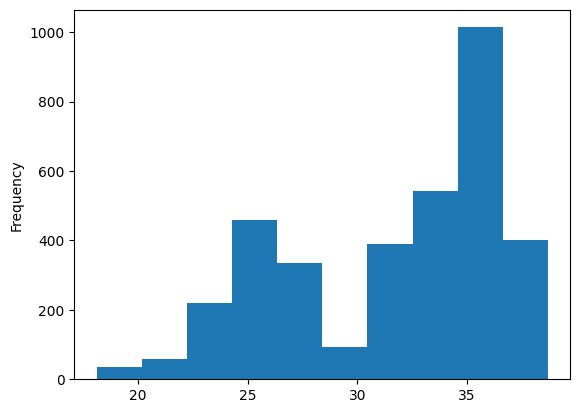

In [5]:
vendas['valor'].plot(kind='hist')

<Axes: xlabel='valor', ylabel='Count'>

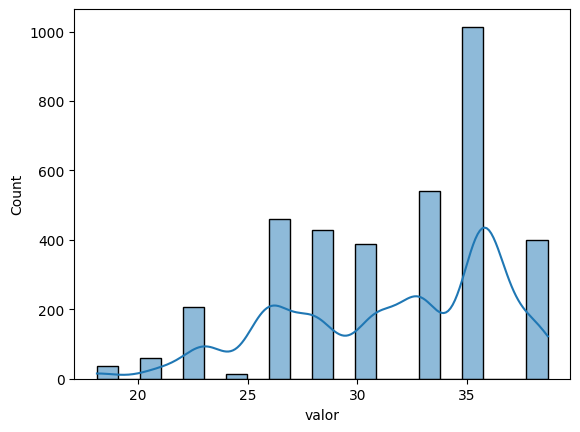

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criando o gráfico

sns.histplot(vendas['valor'], kde=True)

<Axes: ylabel='valor'>

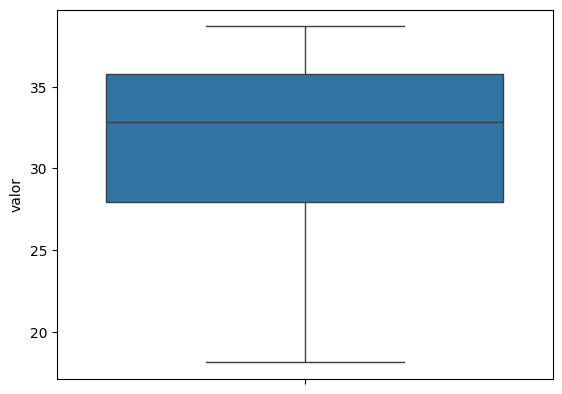

In [8]:
#para localizar outliars

sns.boxplot(vendas['valor'])

<Axes: xlabel='hora_do_dia', ylabel='Count'>

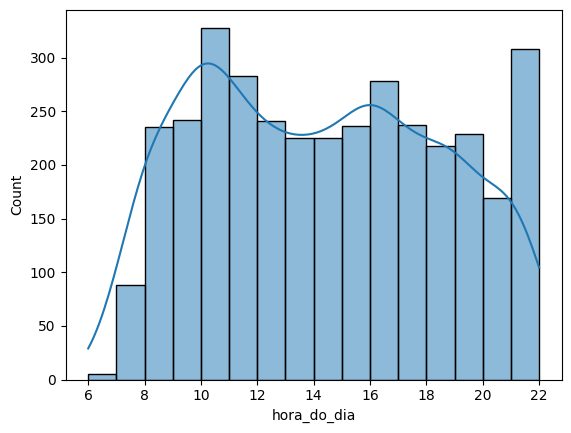

In [9]:
sns.histplot(vendas['hora_do_dia'], kde=True)

<Axes: xlabel='dia_da_semana', ylabel='Count'>

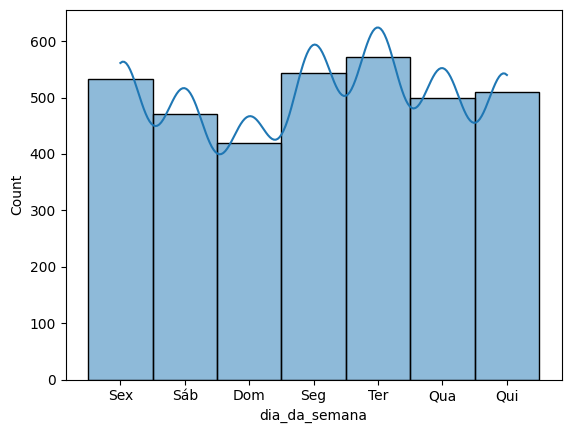

In [10]:
sns.histplot(vendas['dia_da_semana'], kde=True)

<Axes: xlabel='mes', ylabel='Count'>

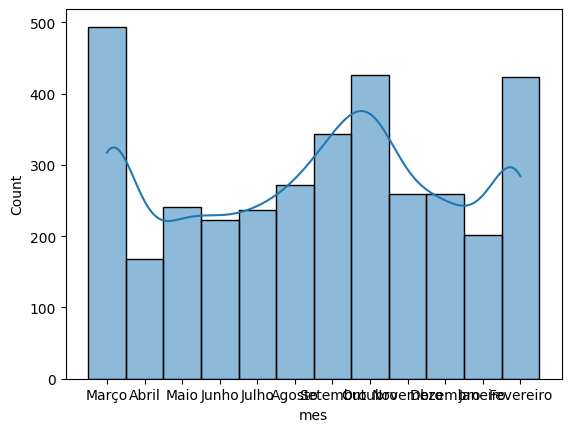

In [11]:
sns.histplot(vendas['mes'], kde=True)

## Referências

* http://www.leg.ufpr.br/~paulojus/estbas/

## Lembrete: Projeto Final

https://colab.research.google.com/drive/11_Oq-eR2l9f-0Nt3MdDWsrVai6xomD8I#scrollTo=0_yHSCs1BJny